
# CIC IDS 2017 Dataset — Visualization & Insights Report

**Project:** Network Intrusion Detection System (CICIDS-2017)   
**Team:**  – Dina Fawzy – Mohamed Farag – Pola Mokhtar – Ahmed Mamdouh – Mustafa Ibrahim  
**Team Leader:** Ahmed Mamdouh   
**Google Drive:** https://drive.google.com/drive/folders/1wa5Y5heNduaFH-T2bIkQAkoXlhiy0QCe?usp=sharing  
**Github Repo:** https://github.com/AhmedELNajjar-dev/Depi-Final-Project  

# 🕵️‍♀️ Deep Dive Analysis: 20 Questions & 20 Plots

**Objective:** To uncover specific patterns, anomalies, and signatures in the network traffic data using a comprehensive visual interrogation.

### 1️⃣. Traffic Distribution
1.  **Global Distribution:** What is the overall ratio of Benign vs. Malicious traffic?
2.  **Attack Landscape:** Excluding normal traffic, which attack types are the most prevalent?

### 2️⃣. Sources & Targets (The "Who")
3.  **Top Talkers:** Which Source IPs generates the most traffic overall?
4.  **Top Attackers:** Which specific Source IPs are responsible for the most malicious traffic?
5.  **Top Victims:** Which Destination IPs are targeted most frequently by attacks?
6.  **Vulnerable Ports:** Which Destination Ports are most heavily targeted by attacks?

### 3️⃣. Temporal Analysis (The "When")
7.  **Daily Rhythm:** How does the total traffic volume fluctuate throughout the day?
8.  **Attack Timeline:** At what specific hours do different attack types peak?

### 4️⃣. Flow Characteristics (The "How")
9.  **Connection Length:** How does Flow Duration differ between Benign and Attack traffic?
10. **Traffic Speed (Bytes):** Do attacks transfer data faster (Bytes/s) than normal users?
11. **Traffic Speed (Packets):** Do attacks send packets at a higher rate (Packets/s)?
12. **Packet Volume:** How does the Total Number of Forward Packets vary by class?

### 5️⃣. Packet Geometry
13. **Packet Size:** Is the Average Packet Size a distinguishing feature for attacks?
14. **Forward vs. Backward:** What is the relationship between Forward and Backward packet lengths?
15. **Header Size:** Do attacks have unusual Forward Header Lengths?
16. **Packet Variance:** Which classes show the highest variance in packet size?

### 6️⃣. Advanced Protocol Behavior
17. **Protocol Usage:** Which network protocols (TCP/UDP) are preferred by attackers?
18. **TCP Window:** How does the Initial TCP Window Size differ for attacks (e.g., PortScan)?
19. **Idleness:** Do specific attacks exhibit distinct "Idle" times compared to normal flows?
20. **Activity Bursts:** How does the "Active Mean" time vary across different traffic labels?



#  Step 1: Import Required Libraries

We import common data science and visualization libraries like **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn**.  
These libraries help with data handling and creating informative plots.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import matplotlib.ticker as mtick


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


#  Step 2: Load the Cleaned CIC IDS 2017 Dataset

The dataset is loaded from Google Drive.  
It represents network traffic records labeled as either **benign** or various types of **attacks**.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

parquet_path = "/content/drive/MyDrive/Depi Project/Cleaned Data/Cleaned_Data.parquet"
df = pd.read_parquet(parquet_path)

print("Data loaded from Parquet with all data types preserved!")


Data loaded from Parquet with all data types preserved!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2520158 entries, 0 to 2520157
Data columns (total 84 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   Source IP                    object        
 1   Source Port                  int32         
 2   Destination IP               object        
 3   Destination Port             int32         
 4   Protocol                     int8          
 5   Timestamp                    datetime64[ns]
 6   Flow Duration                int32         
 7   Total Fwd Packets            int32         
 8   Total Backward Packets       int32         
 9   Total Length of Fwd Packets  int32         
 10  Total Length of Bwd Packets  int32         
 11  Fwd Packet Length Max        int16         
 12  Fwd Packet Length Min        int16         
 13  Fwd Packet Length Mean       float64       
 14  Fwd Packet Length Std        float64       
 15  Bwd Packet Length Max        int16         
 16  

In [ ]:
df.shape

(2520158, 84)


#  Step 3: Convert Timestamp Column

We convert the `Timestamp` column to a proper `datetime` format for any potential time-based analysis.


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])


##  Step 3.1: Simplify Attack Labels

Some attack names are very detailed (e.g., *DoS Hulk*, *DoS GoldenEye*).  
We group them into broader categories like **DoS**, **Brute Force**, and **Web Attack** for easier visualization and analysis.


In [ ]:
if 'df' in locals():
    # --- 2. Prepare Data for Visualization ---

    # Convert Timestamp
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

    # Group Labels for EDA
    label_mapping = {
        'BENIGN': 'BENIGN',
        'DDoS': 'DDoS',
        'DoS Hulk': 'DoS',
        'DoS GoldenEye': 'DoS',
        'DoS slowloris': 'DoS',
        'DoS Slowhttptest': 'DoS',
        'PortScan': 'PortScan',
        'FTP-Patator': 'Brute Force',
        'SSH-Patator': 'Brute Force',
        'Bot': 'Bot',
        'Web Attack  Brute Force': 'Web Attack',
        'Web Attack  XSS': 'Web Attack',
        'Web Attack  Sql Injection': 'Web Attack',
        'Infiltration': 'Infiltration',
        'Heartbleed': 'Heartbleed'
    }

    # Map the labels to a new column
    df['Label_Grouped'] = df['Label'].map(label_mapping)
    # Fill any NaNs created by the map (if some labels weren't in the mapping)
    df['Label_Grouped'] = df['Label_Grouped'].fillna('Other')

    print("Data prepared for visualization with 'Label_Grouped' column.")
    print(df['Label_Grouped'].value_counts())
else:
    print("DataFrame 'df' is not loaded. Please run Cell 2 successfully.")


Data prepared for visualization with 'Label_Grouped' column.
Label_Grouped
BENIGN          2095020
DoS              193709
DDoS             128011
PortScan          90130
Brute Force        9150
Web Attack         2143
Bot                1948
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


In [ ]:
print(df["Label"].value_counts())

Label
BENIGN                        2095020
DoS Hulk                       172810
DDoS                           128011
PortScan                        90130
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack  Brute Force         1470
Web Attack  XSS                  652
Infiltration                       36
Web Attack  Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
print(df["Label_Grouped"].value_counts())

Label_Grouped
BENIGN          2095020
DoS              193709
DDoS             128011
PortScan          90130
Brute Force        9150
Web Attack         2143
Bot                1948
Infiltration         36
Heartbleed           11
Name: count, dtype: int64


# Step 4: Visulizsations

## 1️⃣ Distribution & Sources (Questions 1 - 4)
**Objective:** Analyze the "Big Picture" of the traffic and identify the key actors.

* **Q1 Global Distribution:** Shows the massive scale difference between Benign (millions) and Malicious (thousands) traffic.
* **Q2 Attack Landscape:** Zooms in *only* on the attacks to see which types are most common (likely DoS and PortScan).
* **Q3 & Q4 Top Talkers:** Contrasts the busiest IPs overall vs. the specific IPs responsible for attacks. This helps identify "bad actor" IP addresses.

/tmp/ipython-input-819198627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label_Grouped', data=df, palette='viridis', ax=axes[0, 0])
/tmp/ipython-input-819198627.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_src.index, y=top_src.values, palette='Blues_r', ax=axes[1, 0])
/tmp/ipython-input-819198627.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_atk_src.index, y=top_atk_src.values, palette='Reds_r', ax=axes[1, 1])


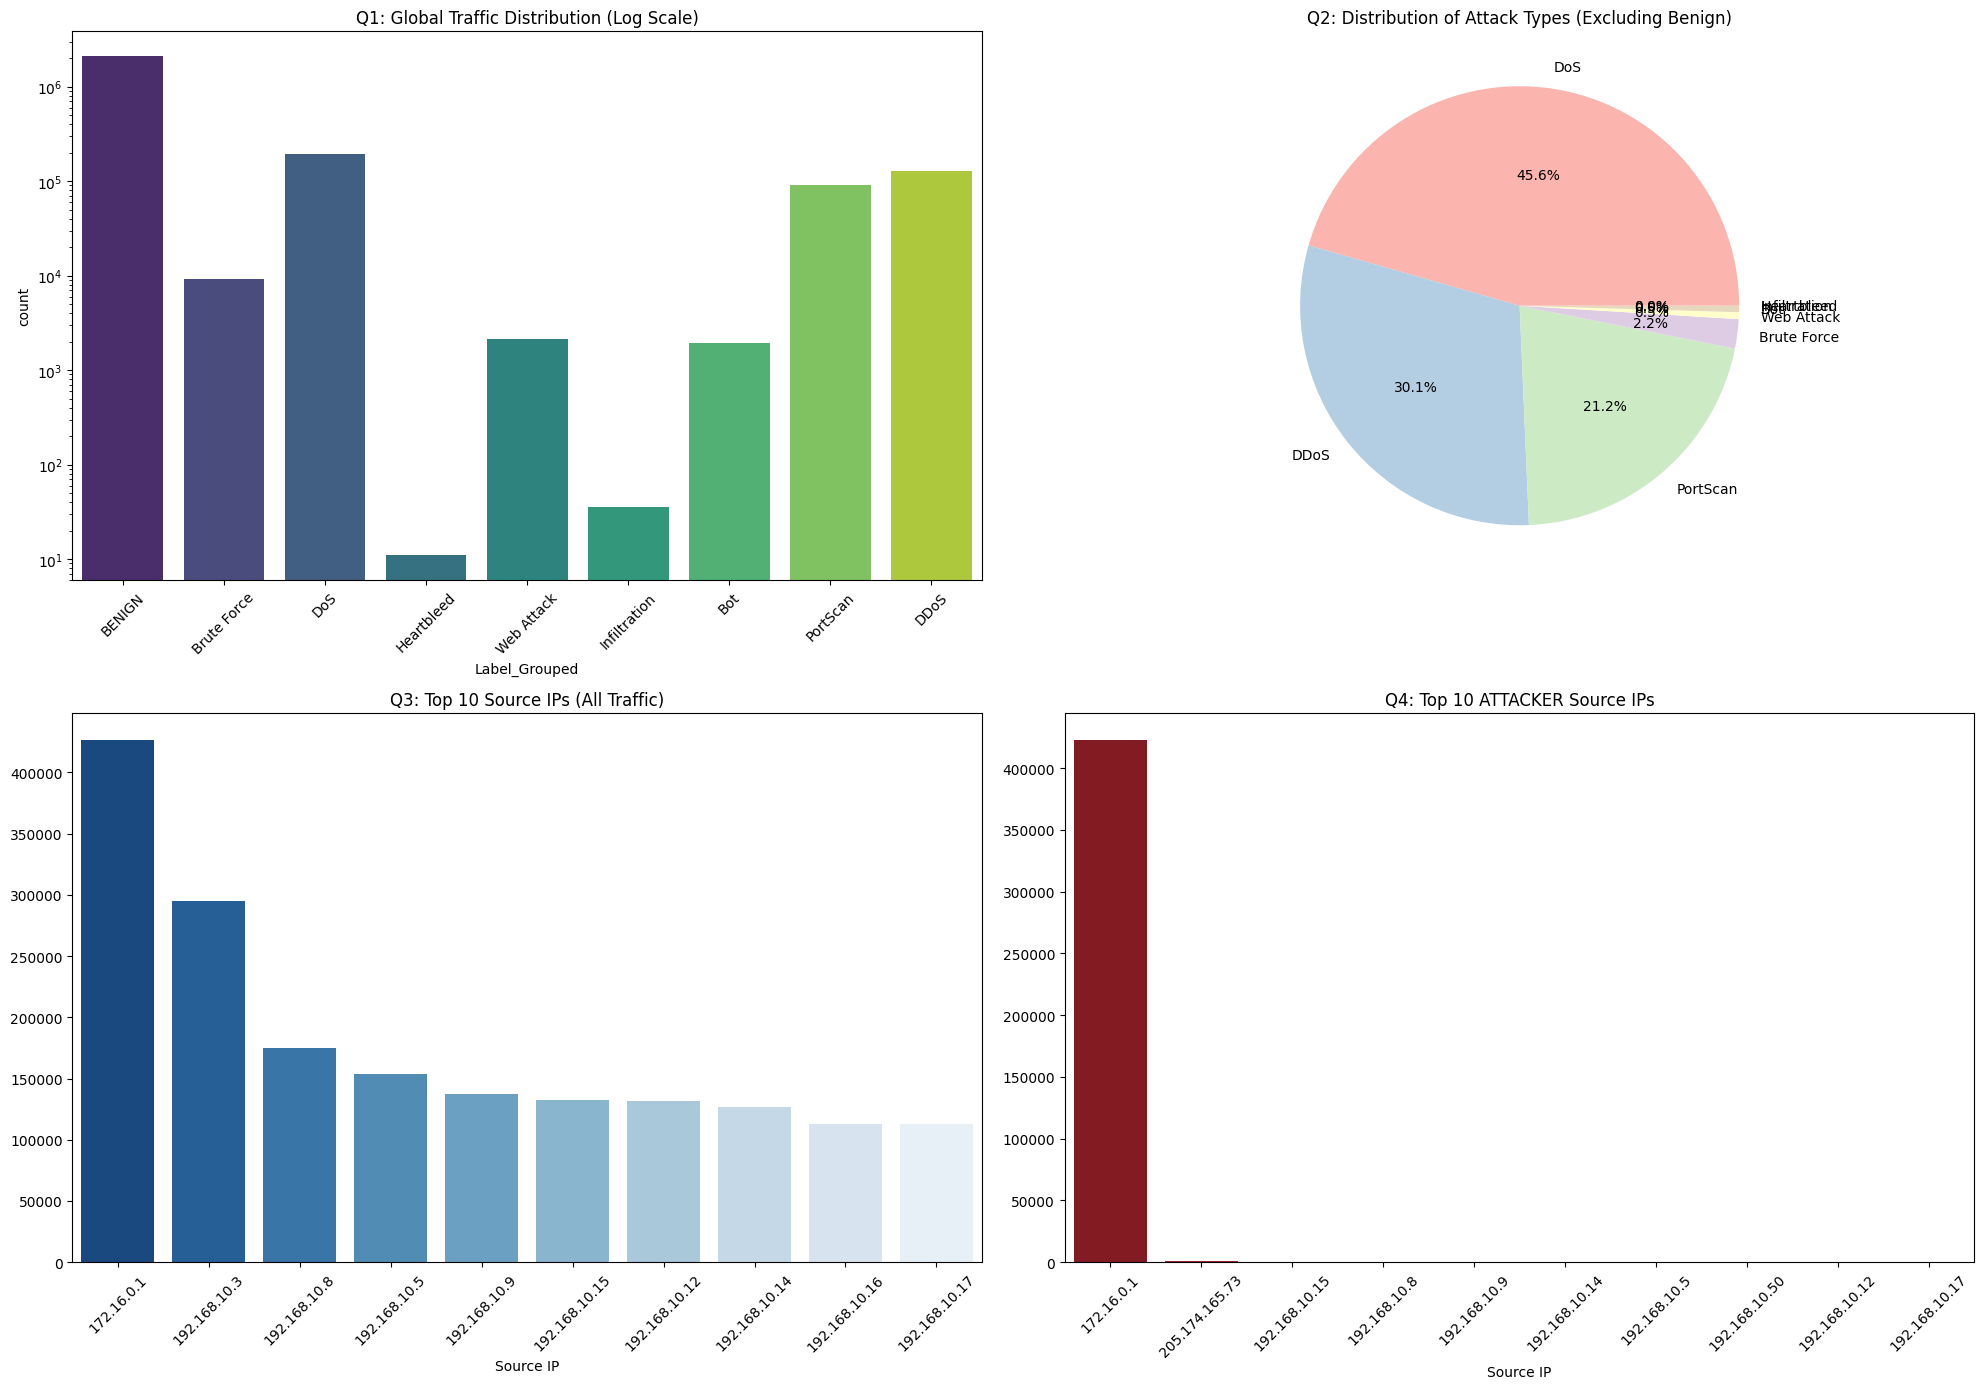

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Q1: Global Distribution
sns.countplot(x='Label_Grouped', data=df, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Q1: Global Traffic Distribution (Log Scale)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Q2: Attack Landscape (No Benign)
attacks_only = df[df['Label_Grouped'] != 'BENIGN']
attacks_only['Label_Grouped'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0, 1], cmap='Pastel1')
axes[0, 1].set_title('Q2: Distribution of Attack Types (Excluding Benign)')
axes[0, 1].set_ylabel('')

# Q3: Top Talkers (Source IP - All)
top_src = df['Source IP'].value_counts().head(10)
sns.barplot(x=top_src.index, y=top_src.values, palette='Blues_r', ax=axes[1, 0])
axes[1, 0].set_title('Q3: Top 10 Source IPs (All Traffic)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Q4: Top Attackers (Source IP - Attacks Only)
top_atk_src = attacks_only['Source IP'].value_counts().head(10)
sns.barplot(x=top_atk_src.index, y=top_atk_src.values, palette='Reds_r', ax=axes[1, 1])
axes[1, 1].set_title('Q4: Top 10 ATTACKER Source IPs')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3️⃣ Targets & Time (Questions 5 - 8)
**Objective:** Identify who is being attacked and when the attacks occur.

* **Q5 Top Victims:** Reveals which internal IPs are targeted most often.
* **Q6 Vulnerable Ports:** Highlights the specific services (e.g., HTTP Port 80) that attackers focus on.
* **Q7 & Q8 Temporal Analysis:**
    * *Daily Rhythm:* Shows the overall traffic volume hour-by-hour.
    * *Attack Heatmap:* A powerful visualization that shows *exactly* when specific attacks (like a Brute Force campaign) started and stopped during the day.

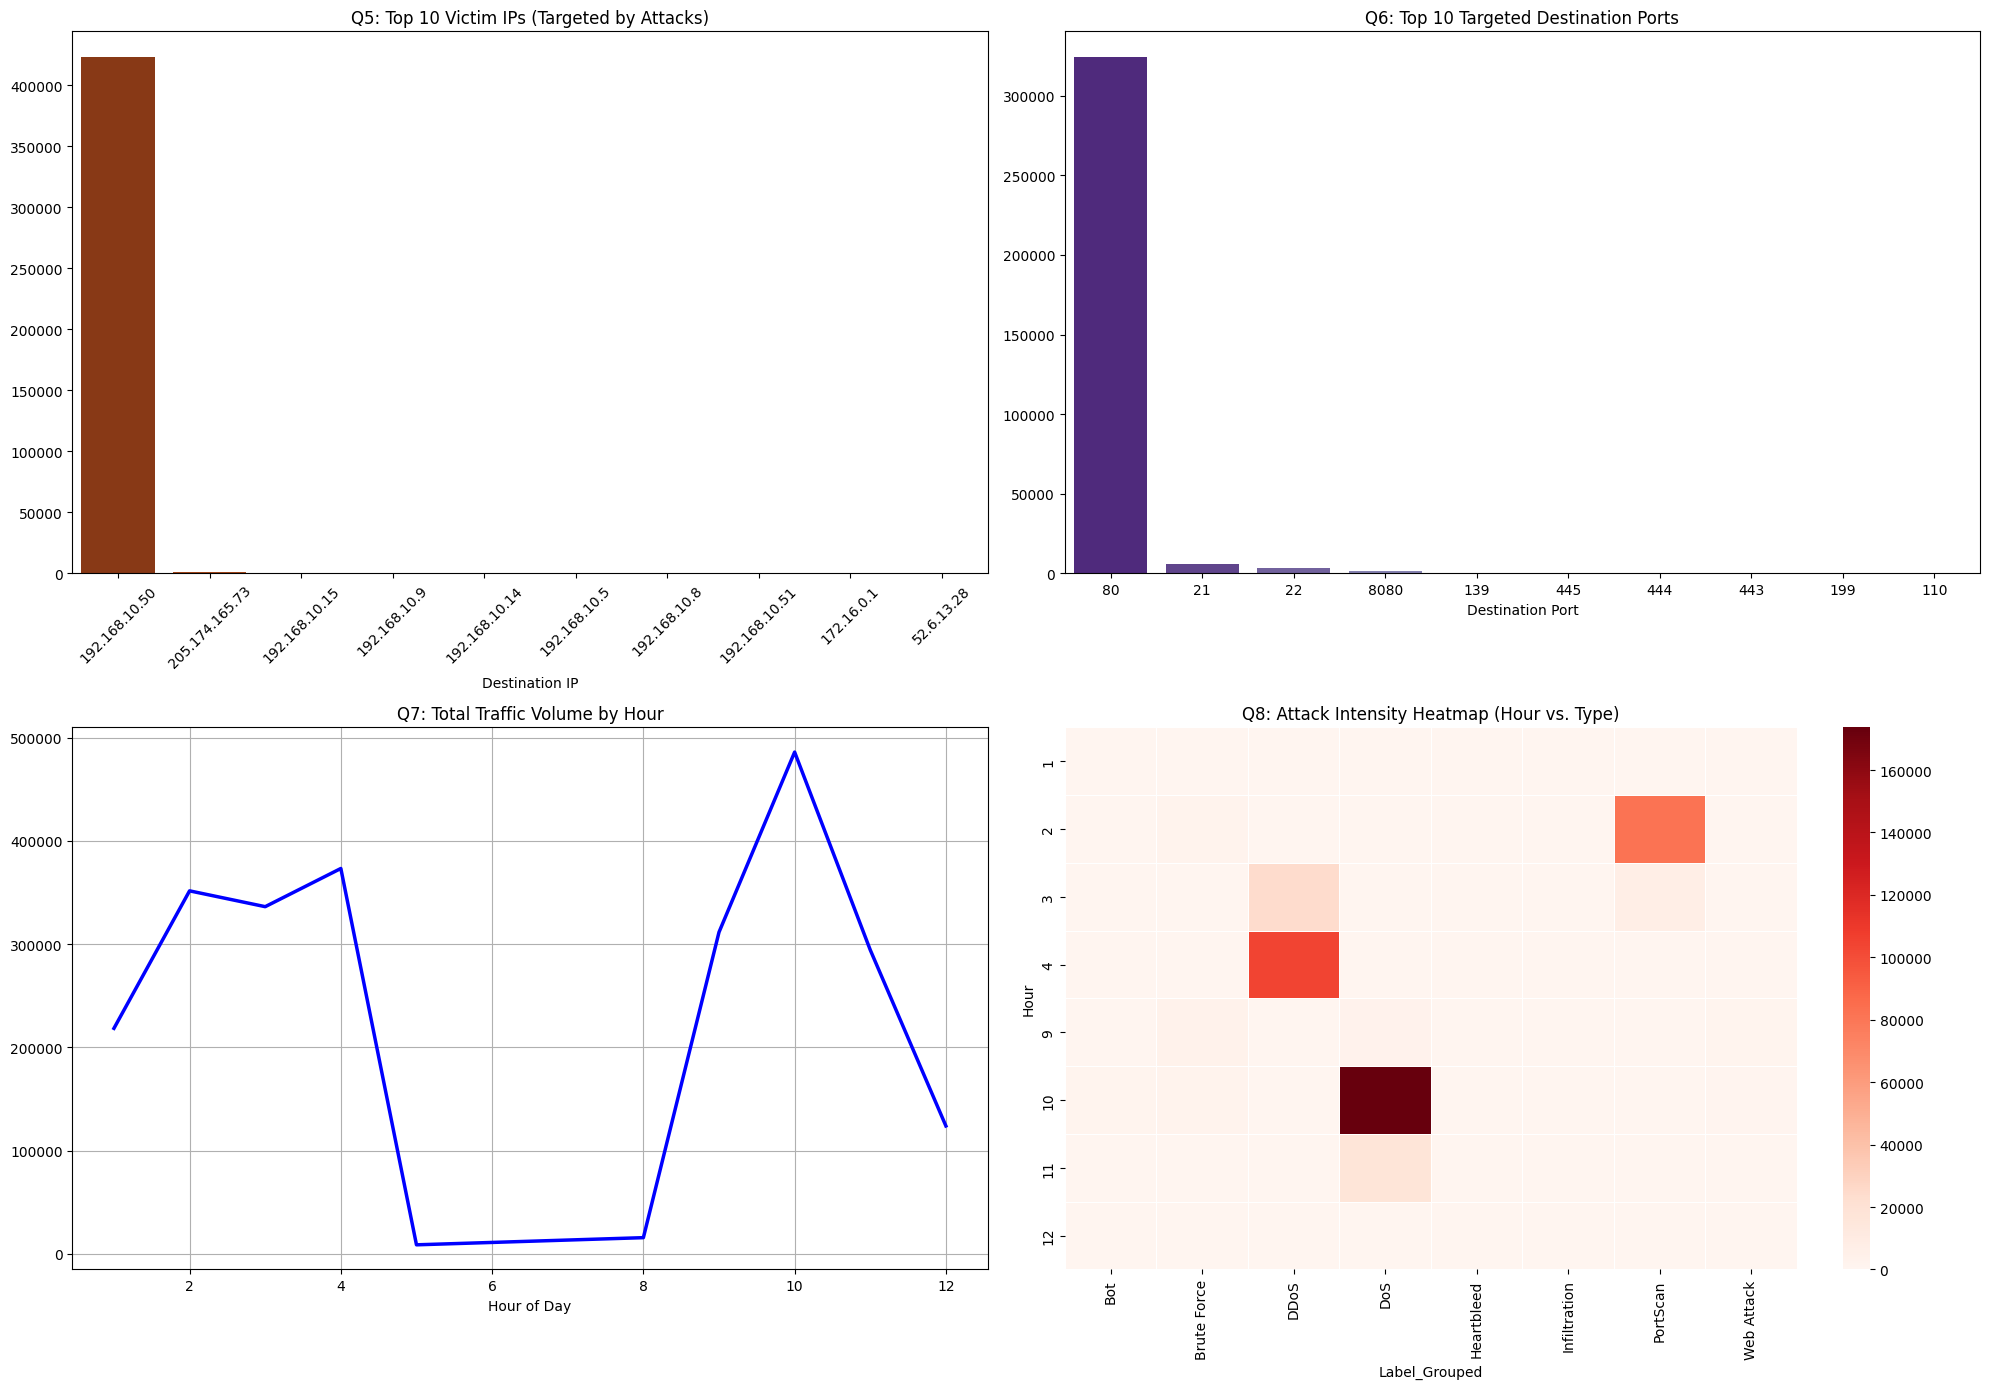

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Q5: Top Victims (Dest IP - Attacks Only)
top_dst = attacks_only['Destination IP'].value_counts().head(10)
# Fix: Added hue=x and legend=False to suppress FutureWarning
sns.barplot(x=top_dst.index, y=top_dst.values, hue=top_dst.index, palette='Oranges_r', ax=axes[0, 0], legend=False)
axes[0, 0].set_title('Q5: Top 10 Victim IPs (Targeted by Attacks)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Q6: Vulnerable Ports
top_ports = attacks_only['Destination Port'].value_counts().head(10)
# Fix: Added hue=x and legend=False to suppress FutureWarning
sns.barplot(x=top_ports.index.astype(str), y=top_ports.values, hue=top_ports.index.astype(str), palette='Purples_r', ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Q6: Top 10 Targeted Destination Ports')

# Q7: Daily Rhythm
df['Hour'] = df['Timestamp'].dt.hour
hourly_counts = df['Hour'].value_counts().sort_index()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, ax=axes[1, 0], linewidth=2.5, color='blue')
axes[1, 0].set_title('Q7: Total Traffic Volume by Hour')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].grid(True)

# Q8: Attack Timeline
# --- FIX START: Refresh attacks_only to include the new 'Hour' column ---
attacks_only = df[df['Label_Grouped'] != 'BENIGN'].copy()
# --- FIX END ---

# Create a pivot table for heatmap
heatmap_data = pd.crosstab(attacks_only['Hour'], attacks_only['Label_Grouped'])
sns.heatmap(heatmap_data, cmap='Reds', ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Q8: Attack Intensity Heatmap (Hour vs. Type)')

plt.tight_layout()
plt.show()

## 4️⃣ Flow Characteristics (Questions 9 - 12)
**Objective:** Analyze the "shape" and "speed" of the traffic flows.

* **Q9 Flow Duration:** Do attacks last a long time (like a slow download) or are they instant (like a ping)?
* **Q10 & Q11 Traffic Speed:** Compares the throughput (Bytes/s) and packet rate (Packets/s). High rates often indicate volumetric attacks like DDoS.
* **Q12 Packet Volume:** Shows if attacks send a huge number of packets or just a few.
* *Note: Log scales are used to make the differences visible.*

/tmp/ipython-input-973310185.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Flow Duration', data=plot_df, palette='Set2', ax=axes[0, 0])
/tmp/ipython-input-973310185.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Flow Bytes/s', data=plot_df, palette='Set2', ax=axes[0, 1])
/tmp/ipython-input-973310185.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Flow Packets/s', data=plot_df, palette='Set2', ax=axes[1, 0])
/tmp/ipython-input-973310185.py:25: FutureWarning: 



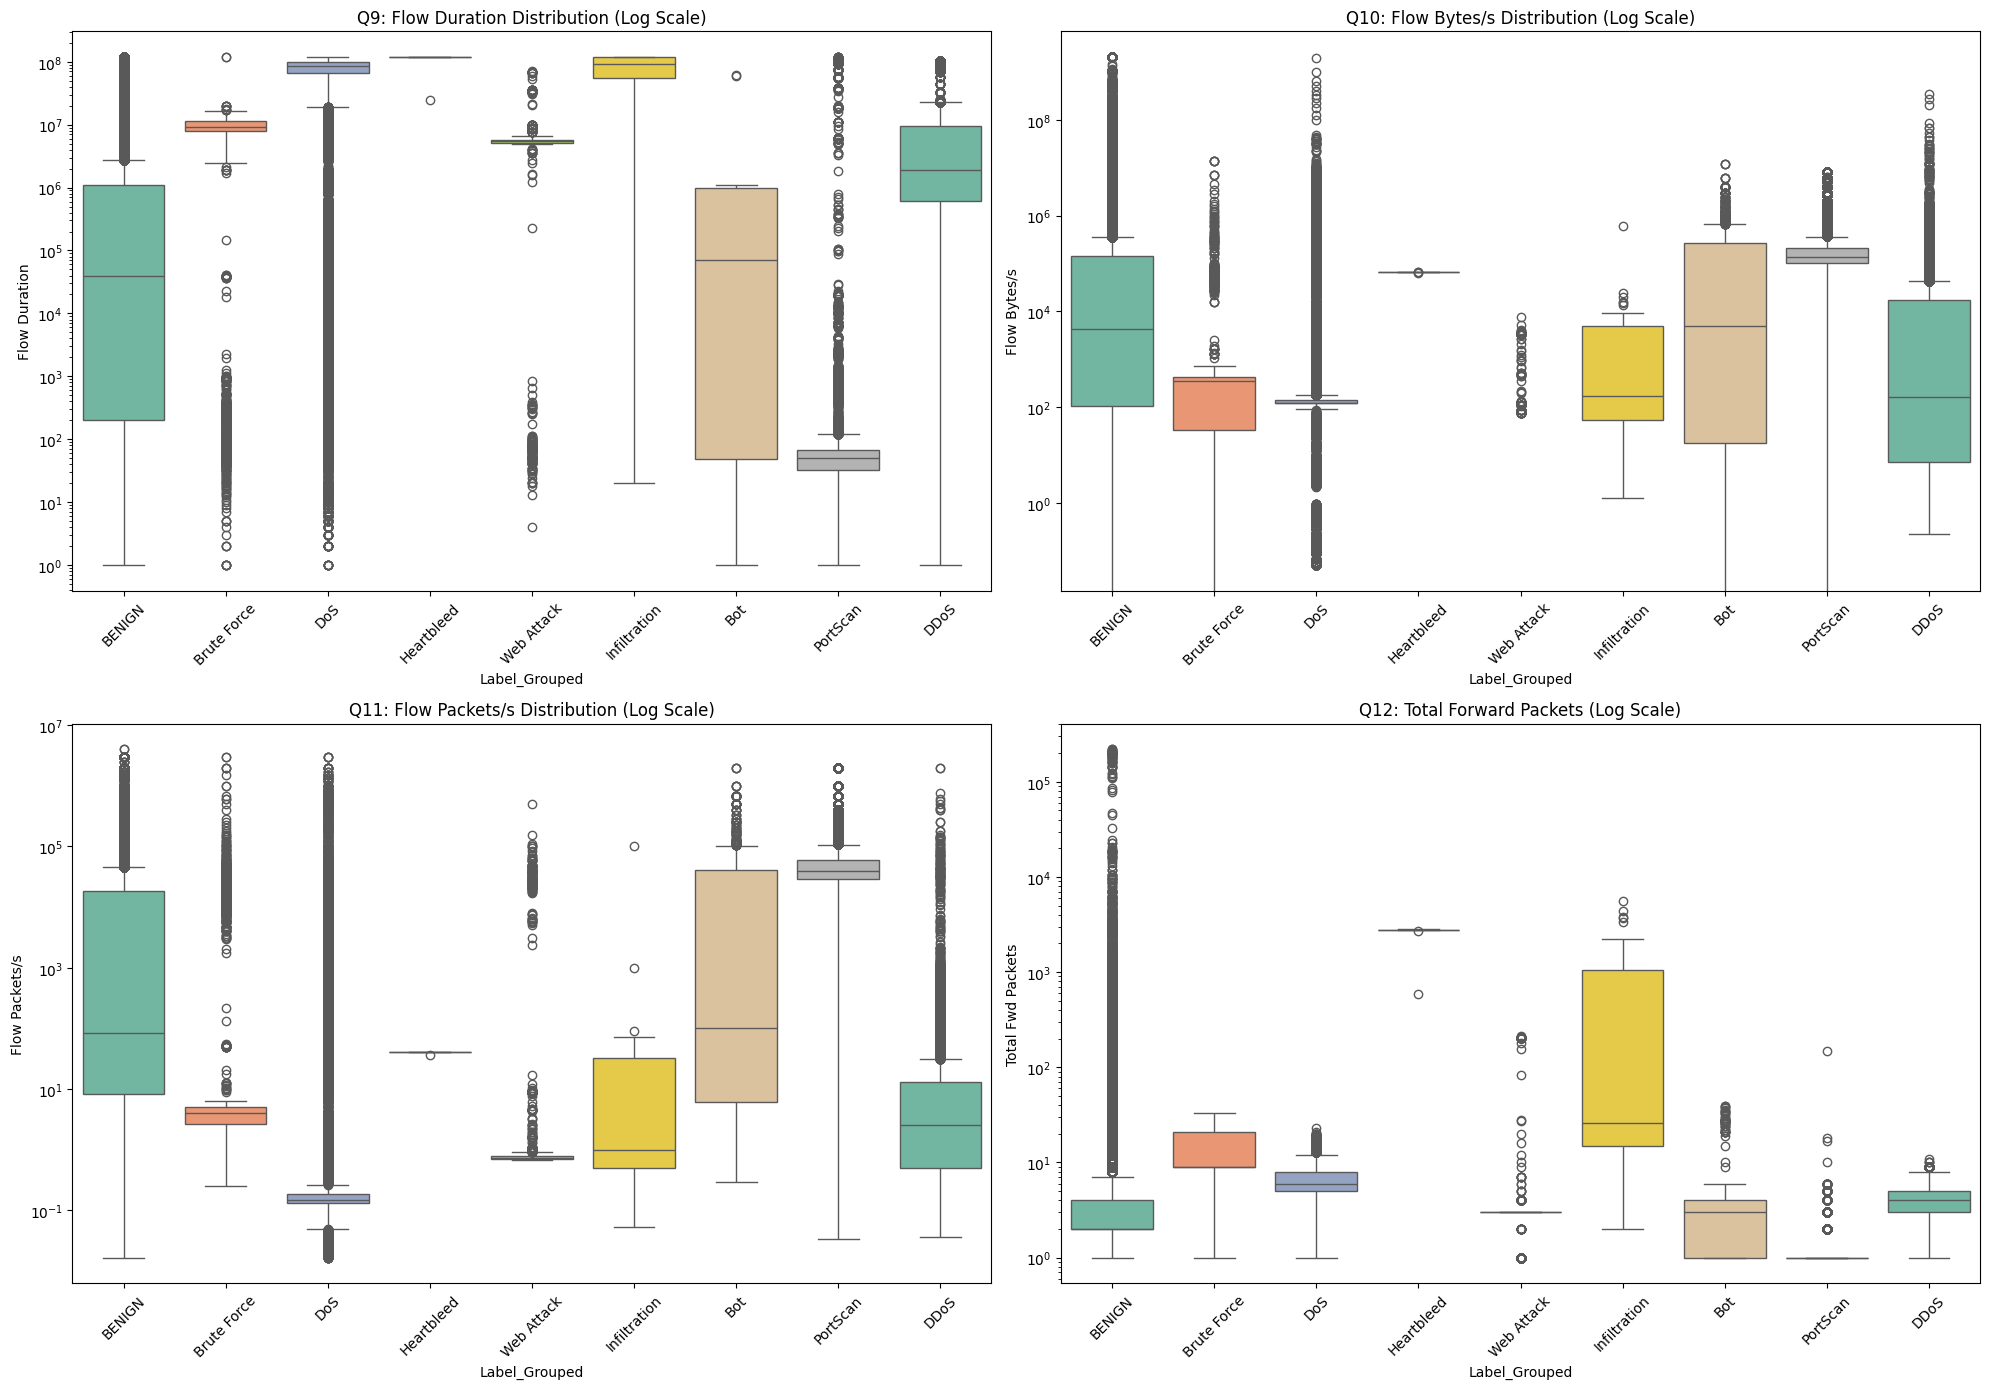

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Helper to clean data for plotting (remove inf/nan)
plot_df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Q9: Flow Duration
sns.boxplot(x='Label_Grouped', y='Flow Duration', data=plot_df, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Q9: Flow Duration Distribution (Log Scale)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Q10: Flow Bytes/s
sns.boxplot(x='Label_Grouped', y='Flow Bytes/s', data=plot_df, palette='Set2', ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Q10: Flow Bytes/s Distribution (Log Scale)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Q11: Flow Packets/s
sns.boxplot(x='Label_Grouped', y='Flow Packets/s', data=plot_df, palette='Set2', ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Q11: Flow Packets/s Distribution (Log Scale)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Q12: Total Fwd Packets
sns.boxplot(x='Label_Grouped', y='Total Fwd Packets', data=plot_df, palette='Set2', ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Q12: Total Forward Packets (Log Scale)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5️⃣ Packet Geometry (Questions 13 - 16)
**Objective:** Examine the physical properties of the packets themselves.

* **Q13 Average Packet Size:** Different attacks have unique "fingerprints." For example, a ping flood uses small, fixed-size packets, while data exfiltration uses large, full packets.
* **Q14 Fwd vs. Bwd Length:** Checks for symmetry. Normal traffic (like browsing) usually has small requests and large responses. Attacks might break this pattern.
* **Q15 Header Length:** Anomalies in header size can indicate malformed packets used to crash systems.
* **Q16 Variance:** High variance suggests a mix of data; low variance suggests automated, repetitive machine traffic.

/tmp/ipython-input-2689873203.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Label_Grouped', y='Average Packet Size', data=plot_df, palette='muted', ax=axes[0, 0])
/tmp/ipython-input-2689873203.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Fwd Header Length', data=plot_df, palette='muted', ax=axes[1, 0])
/tmp/ipython-input-2689873203.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Label_Grouped', y='Packet Length Variance', data=plot_df, estimator=np.median, palette='muted', ax=axes[1, 1])


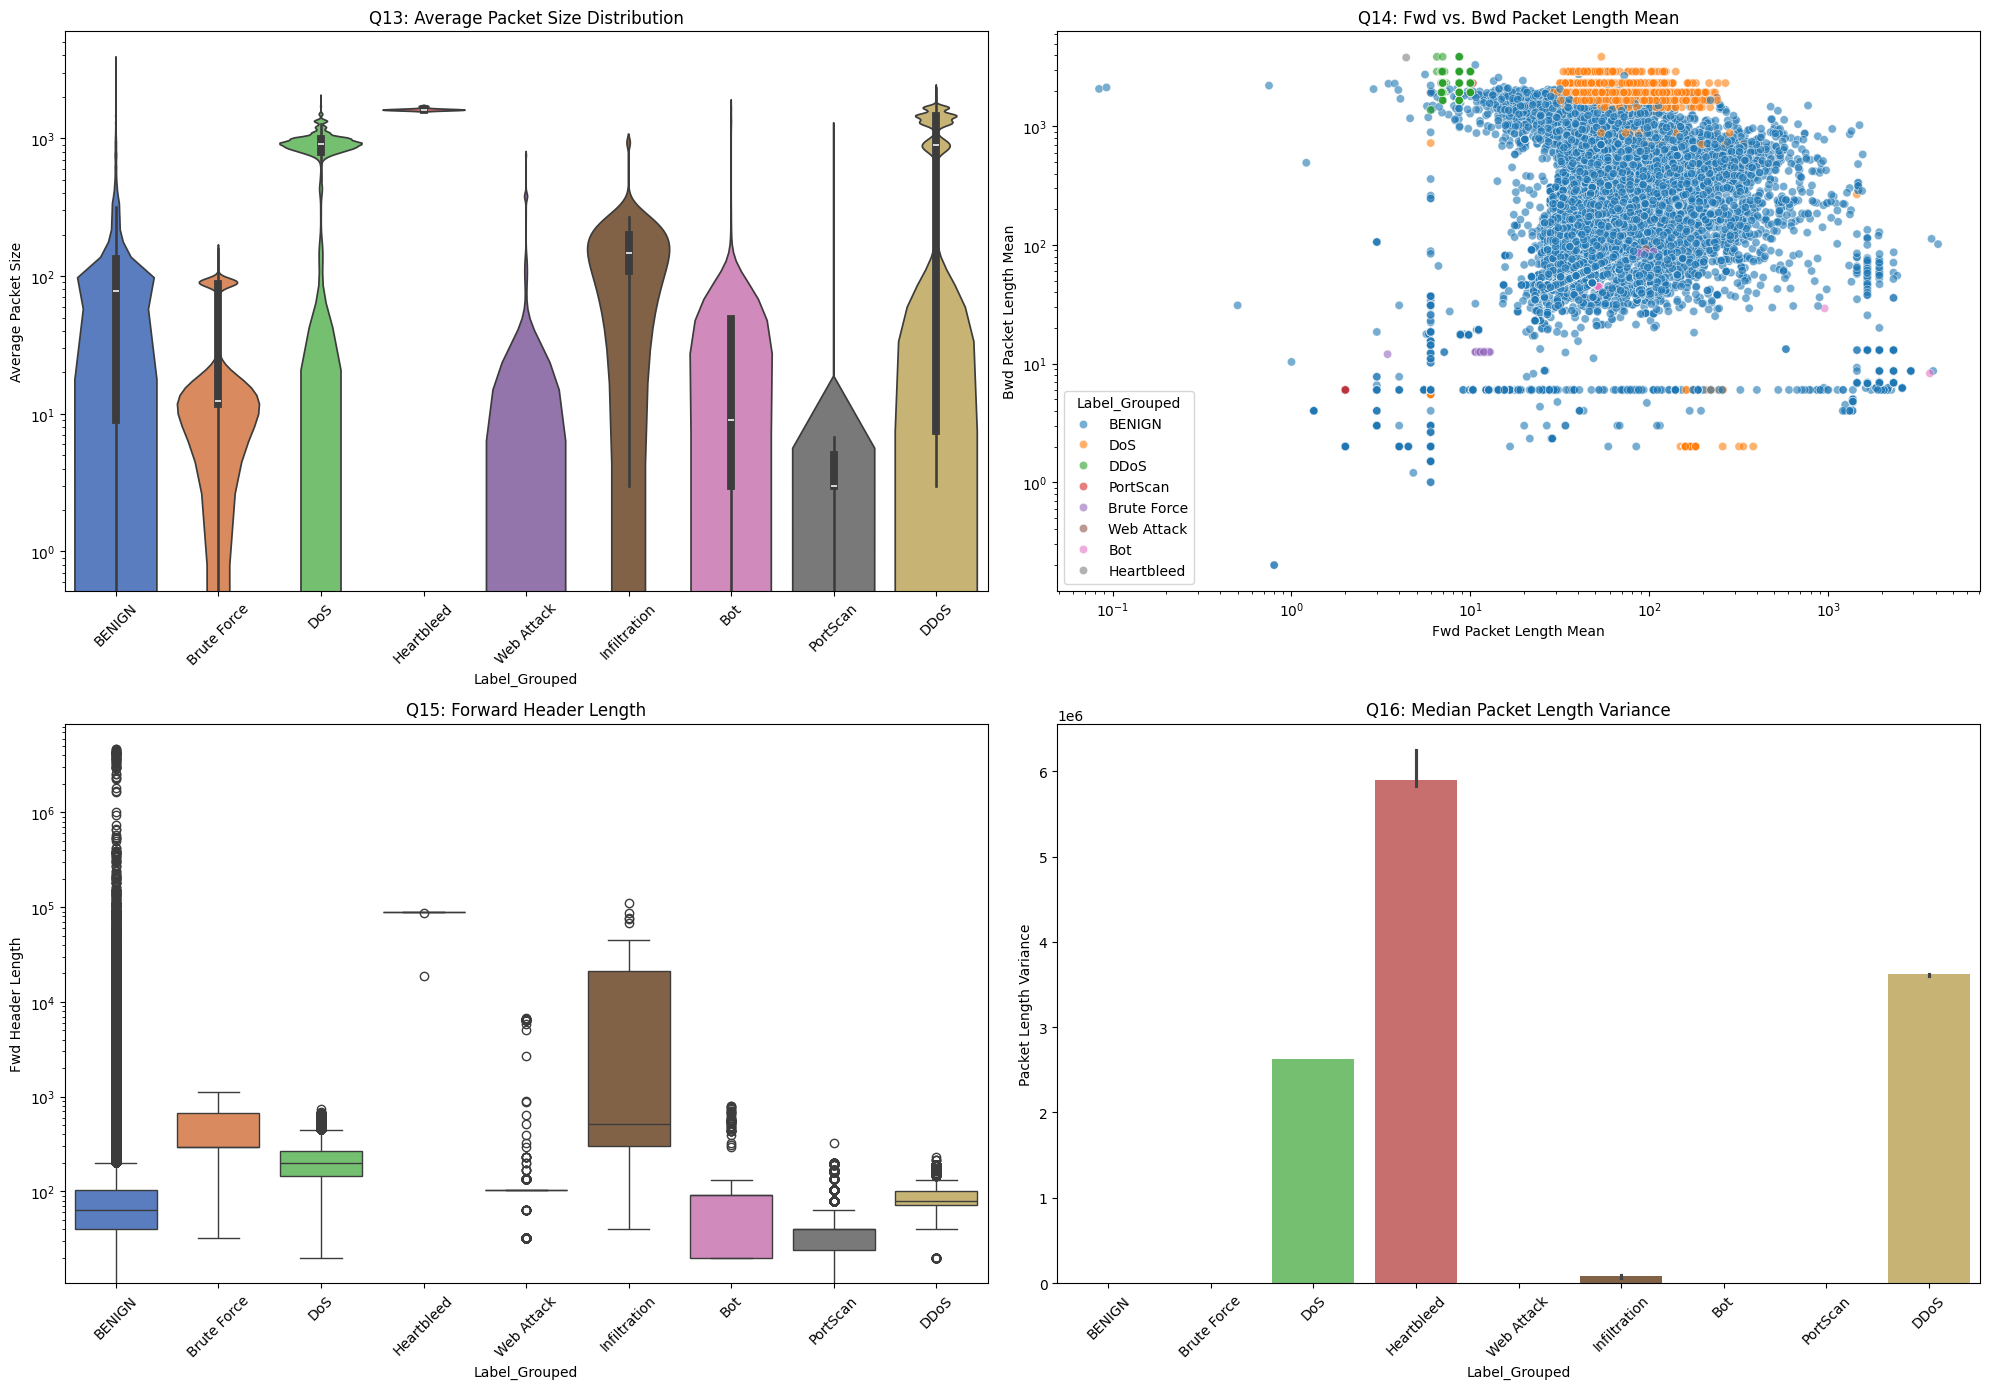

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Q13: Average Packet Size
sns.violinplot(x='Label_Grouped', y='Average Packet Size', data=plot_df, palette='muted', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Q13: Average Packet Size Distribution')
axes[0, 0].tick_params(axis='x', rotation=45)

# Q14: Forward vs Backward Length
# Sampling for scatter plot performance
sample_df = plot_df.sample(50000, random_state=42)
sns.scatterplot(x='Fwd Packet Length Mean', y='Bwd Packet Length Mean', hue='Label_Grouped',
                data=sample_df, alpha=0.6, ax=axes[0, 1])
axes[0, 1].set_title('Q14: Fwd vs. Bwd Packet Length Mean')
axes[0, 1].set_xscale('log'); axes[0, 1].set_yscale('log')

# Q15: Forward Header Length
sns.boxplot(x='Label_Grouped', y='Fwd Header Length', data=plot_df, palette='muted', ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Q15: Forward Header Length')
axes[1, 0].tick_params(axis='x', rotation=45)

# Q16: Packet Length Variance
sns.barplot(x='Label_Grouped', y='Packet Length Variance', data=plot_df, estimator=np.median, palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Q16: Median Packet Length Variance')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6️⃣ Advanced Protocol Behavior (Questions 17 - 20)
**Objective:** Investigate low-level TCP/IP behaviors.

* **Q17 Protocol Usage:** Shows whether attackers prefer TCP (connection-oriented) or UDP (fire-and-forget).
* **Q18 TCP Window:** The "Window Size" is a classic indicator. Port Scanners often use a fixed, specific window size that differs from normal browsers.
* **Q19 & Q20 Active/Idle Times:** Analyzes the rhythm of the connection. Automated bots often have very rigid "sleep" (Idle) and "wake" (Active) cycles, whereas humans are unpredictable.

/tmp/ipython-input-3233534840.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Init_Win_bytes_forward', data=plot_df, palette='coolwarm', ax=axes[0, 1])
/tmp/ipython-input-3233534840.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Idle Mean', data=plot_df, palette='coolwarm', ax=axes[1, 0])
/tmp/ipython-input-3233534840.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Label_Grouped', y='Active Mean', data=plot_df, palette='coolwarm', ax=axes[1, 1])


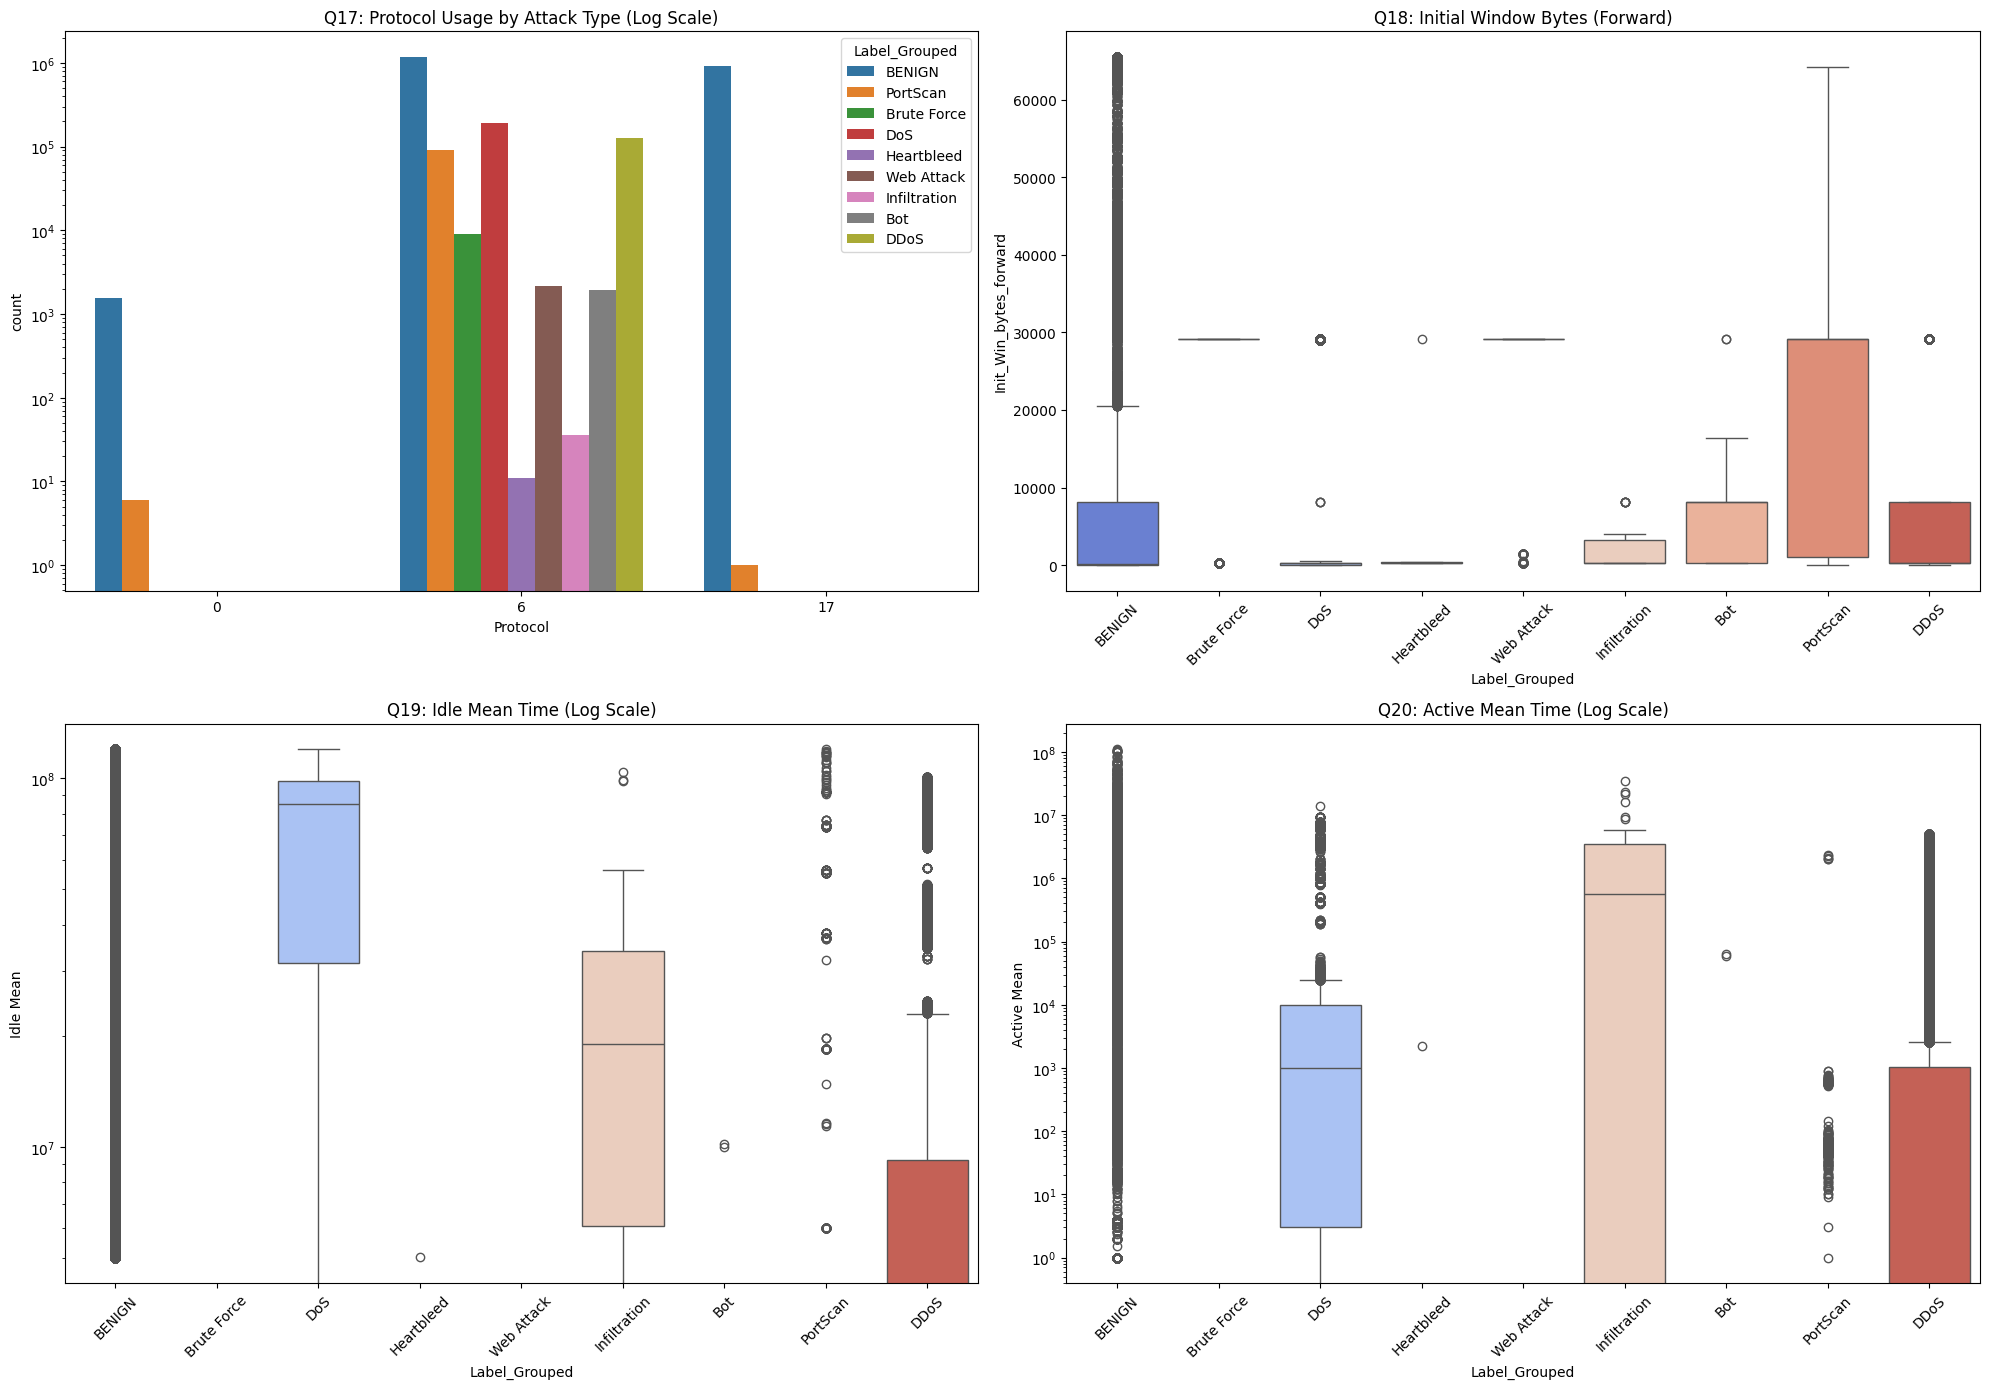

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Q17: Protocol Usage
sns.countplot(x='Protocol', hue='Label_Grouped', data=plot_df, palette='tab10', ax=axes[0, 0])
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Q17: Protocol Usage by Attack Type (Log Scale)')

# Q18: TCP Initial Window (Forward)
sns.boxplot(x='Label_Grouped', y='Init_Win_bytes_forward', data=plot_df, palette='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Q18: Initial Window Bytes (Forward)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Q19: Idle Mean Time
sns.boxplot(x='Label_Grouped', y='Idle Mean', data=plot_df, palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Q19: Idle Mean Time (Log Scale)')
axes[1, 0].tick_params(axis='x', rotation=45)

# Q20: Active Mean Time
sns.boxplot(x='Label_Grouped', y='Active Mean', data=plot_df, palette='coolwarm', ax=axes[1, 1])
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Q20: Active Mean Time (Log Scale)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()